# NB06 - Elastic Net

**Objetivos de aprendizaje**

- Entender por que Lasso puede ser fragil con variables correlacionadas.
- Definir Elastic Net como mezcla de L1 y L2.
- Observar el efecto de agrupamiento entre variables de petalo.
- Usar `solver='saga'`, el solver de scikit-learn que soporta Elastic Net.
- Visualizar coeficientes y frontera de decision.

En todo el notebook mantenemos la convencion global del repositorio: `virginica = 1` es la clase positiva y `versicolor = 0` es la clase negativa.

**Referencias de este notebook**

- Zou & Hastie (2005): introducen Elastic Net y el grouping effect.
- Defazio, Bach & Lacoste-Julien (2014): desarrollan SAGA, solver usado para L1/Elastic Net.
- Murphy (2012): presenta penaltis combinados desde una mirada probabilistica.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## 1. Motivacion: variables correlacionadas

Lasso tiende a escoger una variable entre varias correlacionadas. Elastic Net agrega una parte L2 para repartir peso y mantener grupos, lo que Zou & Hastie (2005) llamaron efecto de agrupamiento.


In [2]:
data = load_processed_splits(DATA_DIR)
X_train = data["X_train"]
X_train_scaled = data["X_train_scaled"]
y_train = data["y_train"]
feature_names = data["feature_names"]

corr_petals = X_train[["petal length (cm)", "petal width (cm)"]].corr().iloc[0, 1]
print(f"Correlacion petal length/petal width en train: {corr_petals:.3f}")


Correlacion petal length/petal width en train: 0.837


## 2. Penalti Elastic Net

Elastic Net combina L1 y L2. `l1_ratio=0` se comporta como Ridge, `l1_ratio=1` como Lasso, y valores intermedios mezclan sparsity con estabilidad. En scikit-learn, `saga` es el solver que soporta `penalty='elasticnet'`; requiere datos escalados y suele necesitar mas iteraciones.


In [3]:
l1_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]
C = 0.35
coef_rows = []

for ratio in l1_ratios:
    # SAGA maneja penalizaciones no suaves como L1 y mezclas Elastic Net.
    model = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=ratio,
        C=C,
        max_iter=20000,
        tol=1e-4,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)
    for feature, coef in zip(feature_names, model.coef_.ravel()):
        coef_rows.append({"l1_ratio": ratio, "feature": feature, "coeficiente": coef})

coef_df = pd.DataFrame(coef_rows)
display(coef_df.pivot(index="l1_ratio", columns="feature", values="coeficiente").round(4))


feature,petal length (cm),petal width (cm),sepal length (cm),sepal width (cm)
l1_ratio,,,,
0.00,1.2097,1.5839,0.1369,-0.103
0.25,1.2450,1.6513,0.0000,0.000
0.50,1.2336,1.7617,0.0000,0.000
0.75,1.1783,1.9500,0.0000,0.000
1.00,0.8688,2.4705,0.0000,0.000


## 3. Exploracion visual de coeficientes


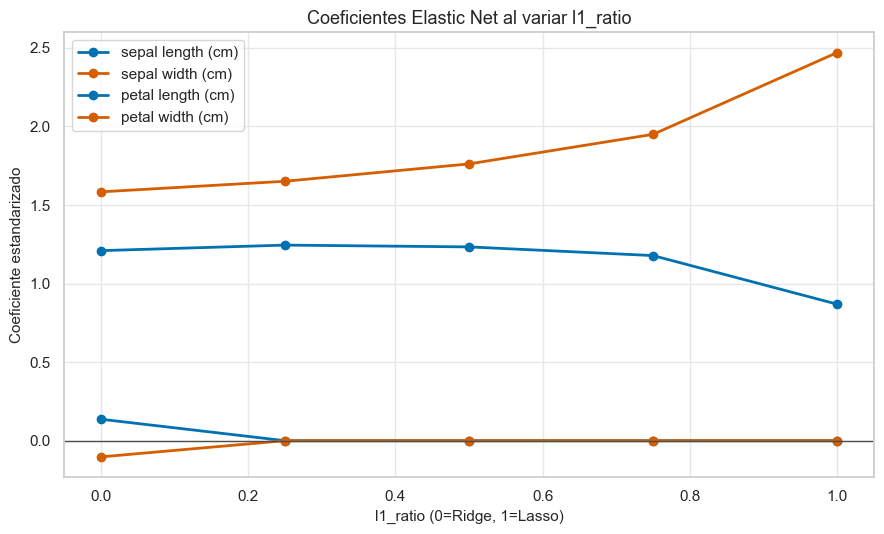

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for feature in feature_names:
    subset = coef_df[coef_df["feature"] == feature]
    ax.plot(subset["l1_ratio"], subset["coeficiente"], marker="o", linewidth=2, label=feature)
ax.axhline(0, color=COLOR_PALETTE["neutral"], linewidth=1)
ax.set_title("Coeficientes Elastic Net al variar l1_ratio")
ax.set_xlabel("l1_ratio (0=Ridge, 1=Lasso)")
ax.set_ylabel("Coeficiente estandarizado")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretacion.** Al aumentar `l1_ratio`, el comportamiento se acerca a Lasso y algunos coeficientes pueden apagarse. En valores intermedios, Elastic Net conserva parte de la estabilidad L2 mientras permite sparsity.


## 4. Demostracion empirica del efecto de agrupamiento


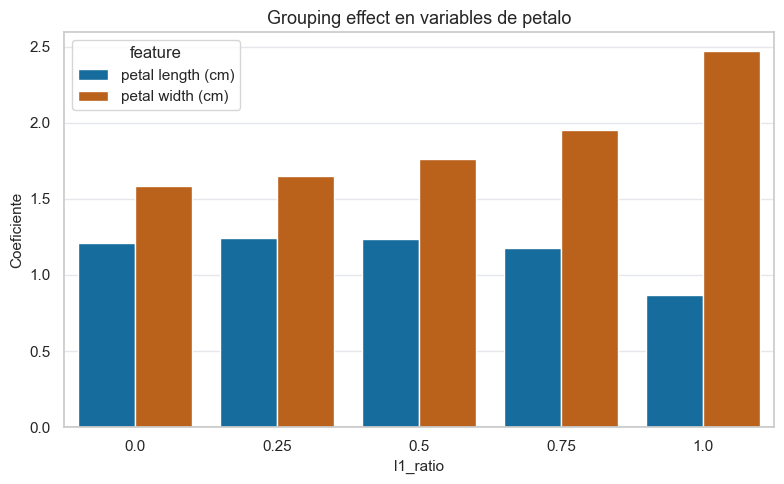

In [5]:
# Comparamos especificamente las dos variables de petalo, que estan
# correlacionadas. Elastic Net tiende a repartir el peso mas que Lasso puro.
petal_df = coef_df[coef_df["feature"].isin(["petal length (cm)", "petal width (cm)"])]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=petal_df, x="l1_ratio", y="coeficiente", hue="feature", ax=ax)
ax.axhline(0, color=COLOR_PALETTE["neutral"], linewidth=1)
ax.set_title("Grouping effect en variables de petalo")
ax.set_xlabel("l1_ratio")
ax.set_ylabel("Coeficiente")
fig.tight_layout()
plt.show()


**Interpretacion.** Cuando las variables estan correlacionadas, la parte L2 ayuda a que ambas conserven informacion compartida. Zou & Hastie (2005) proponen Elastic Net precisamente para evitar que Lasso elija arbitrariamente una variable y descarte otra similar.


## 5. Frontera de decision Elastic Net en 2D


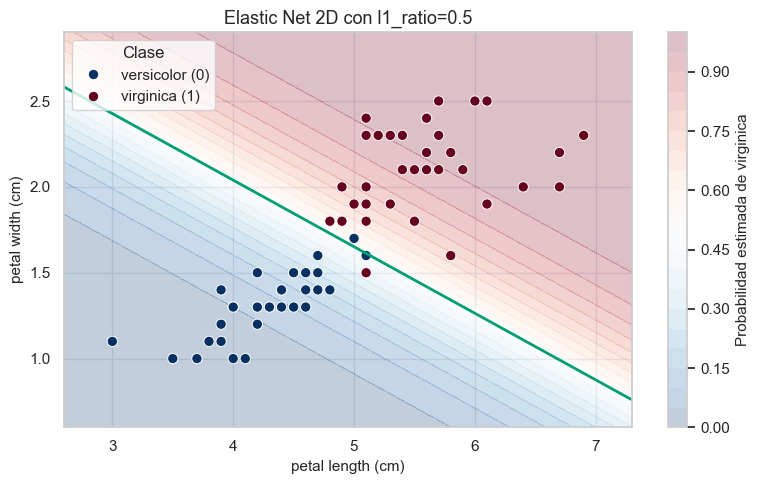

In [6]:
features_2d = ["petal length (cm)", "petal width (cm)"]
model_2d = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        l1_ratio=0.5,
        C=0.35,
        max_iter=20000,
        random_state=RANDOM_STATE,
    ),
)
model_2d.fit(X_train[features_2d], y_train)
plot_decision_boundary(
    model_2d,
    X_train[features_2d],
    y_train,
    features_2d,
    "Elastic Net 2D con l1_ratio=0.5",
)
plt.show()


**Interpretacion.** La frontera mezcla simplicidad y estabilidad: no es tan extrema como un modelo sin penalizacion y no necesariamente apaga una variable como Lasso fuerte.


## Resumen y conexion con la literatura

Zou & Hastie (2005) introdujeron Elastic Net para combinar seleccion L1 con estabilidad L2 y describieron el efecto de agrupamiento observado en variables correlacionadas. Defazio, Bach & Lacoste-Julien (2014) aportan SAGA, el algoritmo que scikit-learn usa para resolver penalizaciones L1/Elastic Net a escala. Murphy (2012) ayuda a leer estos penaltis como preferencias probabilisticas por modelos simples pero no excesivamente fragiles.
